# Relative Rubidium Line fits

Fits the frequency offset and amplitude scale factor for all other values fixed.

## Imports and function definitions

In [1]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model, VoigtModel
from pathlib import Path
import pandas as pd
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import erfc


def pressure_torr(temp_K: float) -> float:
    if temp_K < 39.31:
        logp = - 94.04826 - 1961.258 / temp_K - \
            0.03771687 * temp_K + 42.57526 * np.log10(temp_K)
    else:
        logp = 15.88253 - 4529.635 / temp_K + 0.00058663 * \
            temp_K - 2.99138 * np.log10(temp_K)
    return 10 ** logp


def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (kB * temp_K)

## Loading Data and Parameters

In [9]:

datapath = Path(
    r'/home/mike/Documents/Boulder_PhD/Data/20251023_10h18m12s/rb_cepstral.csv')
data = pd.read_csv(datapath)
full_axis = data['Optical Axis (Hz)'].to_numpy()
full_spectrum = data[' Real Spectrum'].to_numpy()

# Experimental parameters
temp_K = 273+30 
cell_length = .075

mass_85 = au * 84.911789732
mass_87 = au * 86.909180520

ratio_85 = .7217
ratio_87 = .2783

nuc_spin_degen_85 = 12
nuc_spin_degen_87 = 8

nu0_D1 = 377107407.299e6
nu0_D2 = 384230426.6e6

Gamma_D1 = 2 * np.pi * 5.746e6
Gamma_D2 = 2 * np.pi * 6.065e6

lam_D1 = 794.979e-9
lam_D2 = 780.241e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass_85) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass_87)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# D2 dict

isotopes = {'85': {}, '87': {}}
lines = {'D1': deepcopy(isotopes), 'D2': deepcopy(isotopes)}

lines['D1']['87']['Fg2Fe1'] = {'center': nu0_D1 - 3014.644e6, 'cf2': 5/18}
lines['D1']['87']['Fg2Fe2'] = {'center': nu0_D1 - 2202.381e6, 'cf2': 5/18}

lines['D1']['85']['Fg3Fe2'] = {'center': nu0_D1 - 1497.657e6, 'cf2': 35/81}
lines['D1']['85']['Fg3Fe3'] = {'center': nu0_D1 - 1135.721e6, 'cf2': 28/81}

lines['D1']['85']['Fg2Fe2'] = {'center': nu0_D1 + 1538.063e6, 'cf2': 10/81}
lines['D1']['85']['Fg2Fe3'] = {'center': nu0_D1 + 1900.087e6, 'cf2': 35/81}

lines['D1']['87']['Fg1Fe1'] = {'center': nu0_D1 + 3820.046e6, 'cf2': 1/18}
lines['D1']['87']['Fg1Fe2'] = {'center': nu0_D1 + 4632.339e6, 'cf2': 5/18}

lines['D2']['87']['Fg2Fe1'] = {'center': nu0_D2 - 2735.05e6, 'cf2': 1/18}
lines['D2']['87']['Fg2Fe2'] = {'center': nu0_D2 - 2578.11e6, 'cf2': 5/18}
lines['D2']['87']['Fg2Fe3'] = {'center': nu0_D2 - 2311.26e6, 'cf2': 7/9}

lines['D2']['85']['Fg3Fe2'] = {'center': nu0_D2 - 1371.29e6, 'cf2': 10/81}
lines['D2']['85']['Fg3Fe3'] = {'center': nu0_D2 - 1307.87e6, 'cf2': 35/81}
lines['D2']['85']['Fg3Fe4'] = {'center': nu0_D2 - 1186.91e6, 'cf2': 1}

lines['D2']['85']['Fg2Fe1'] = {'center': nu0_D2 + 1635.454e6, 'cf2': 1/3}
lines['D2']['85']['Fg2Fe2'] = {'center': nu0_D2 + 1664.714e6, 'cf2': 35/81}
lines['D2']['85']['Fg2Fe3'] = {'center': nu0_D2 + 1728.134e6, 'cf2': 28/81}

lines['D2']['87']['Fg1Fe0'] = {'center': nu0_D2 + 4027.403e6, 'cf2': 1/9}
lines['D2']['87']['Fg1Fe1'] = {'center': nu0_D2 + 4099.625e6, 'cf2': 5/18}
lines['D2']['87']['Fg1Fe2'] = {'center': nu0_D2 + 4256.57e6, 'cf2': 5/18}

for line, isotopes in lines.items():
    for isotope, transitions in isotopes.items():
        for transition, props in transitions.items():
            if isotope == '85':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_85 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_85 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
            elif isotope == '87':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_87 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_87 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)


## Fit D2s

[[Model]]
    ((((((((((((Model(constant, prefix='bkg_') + Model(voigt, prefix='v_Fg3Fe2_85')) + Model(voigt, prefix='v_Fg3Fe3_85')) + Model(voigt, prefix='v_Fg3Fe4_85')) + Model(voigt, prefix='v_Fg2Fe1_85')) + Model(voigt, prefix='v_Fg2Fe2_85')) + Model(voigt, prefix='v_Fg2Fe3_85')) + Model(voigt, prefix='v_Fg2Fe1_87')) + Model(voigt, prefix='v_Fg2Fe2_87')) + Model(voigt, prefix='v_Fg2Fe3_87')) + Model(voigt, prefix='v_Fg1Fe0_87')) + Model(voigt, prefix='v_Fg1Fe1_87')) + Model(voigt, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 70
    # data points      = 121
    # variables        = 2
    chi-square         = 0.16443895
    reduced chi-square = 0.00138184
    Akaike info crit   = -794.721784
    Bayesian info crit = -789.130202
    R-squared          = 0.96464603
[[Variables]]
    bkg_c:                  1 (fixed)
    xoffset:                2.4582e+08 +/- 5108443.26 (2.08%) (init = 0)
    amp_scale:              32716816.4 +/- 4

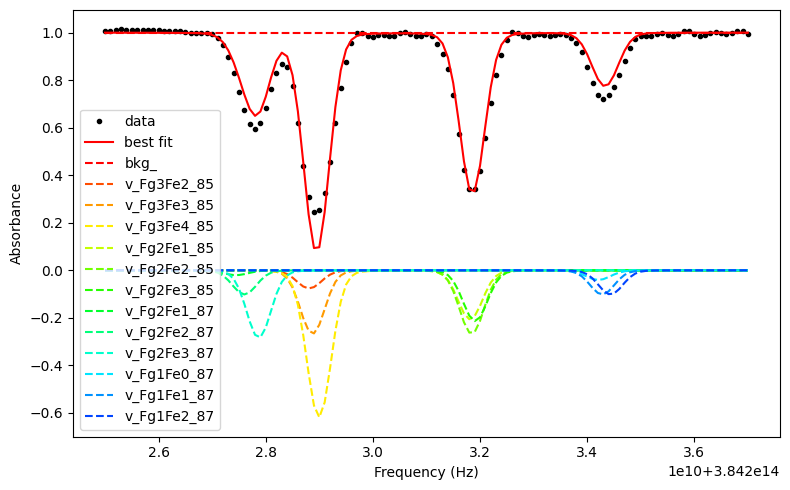

In [10]:
# D2 Fits ######################################3

mask = (full_axis >= 384.225e12) & (full_axis <= 384.237e12)
axis = full_axis[mask]
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1, vary=False)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1)

for isotope, transitions in lines['D2'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = VoigtModel(prefix=prefix)
        model += m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}amplitude'].expr = f'-{prefix}amp_rel * amp_scale'
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel - xoffset'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
for i, x in enumerate(result.eval_components(x=axis).items()):
    name = x[0]
    comp = x[1]
    plt.plot(axis, np.real(comp), '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

## Fit D1s

[[Model]]
    ((((((((Model(constant, prefix='bkg_') + Model(voigt, prefix='v_Fg3Fe2_85')) + Model(voigt, prefix='v_Fg3Fe3_85')) + Model(voigt, prefix='v_Fg2Fe2_85')) + Model(voigt, prefix='v_Fg2Fe3_85')) + Model(voigt, prefix='v_Fg2Fe1_87')) + Model(voigt, prefix='v_Fg2Fe2_87')) + Model(voigt, prefix='v_Fg1Fe1_87')) + Model(voigt, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 70
    # data points      = 110
    # variables        = 2
    chi-square         = 0.18287583
    reduced chi-square = 0.00169329
    Akaike info crit   = -699.937109
    Bayesian info crit = -694.536148
    R-squared          = 0.82611235
[[Variables]]
    bkg_c:                  1 (fixed)
    xoffset:                3.2791e+08 +/- 17009378.3 (5.19%) (init = 0)
    amp_scale:              29484730.2 +/- 1169871.40 (3.97%) (init = 1)
    v_Fg3Fe2_85amplitude:  -1.4292e+08 +/- 5670707.03 (3.97%) == '-v_Fg3Fe2_85amp_rel * amp_scale'
    v_Fg3Fe2_85center:      

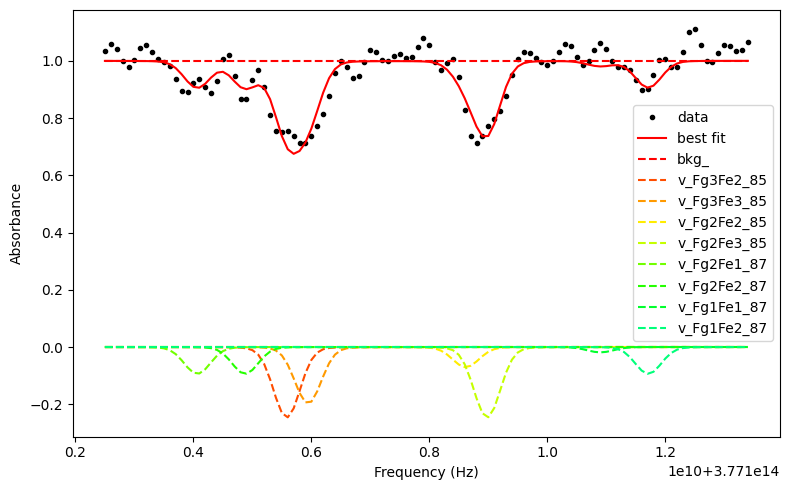

In [11]:
mask = (full_axis >= nu0_D1 - 5e9) & (full_axis <= nu0_D1 + 6e9) 
axis = full_axis[mask]
spectrum = full_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1, vary=False)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1)

for isotope, transitions in lines['D1'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = VoigtModel(prefix=prefix)
        model += m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}amplitude'].expr = f'-{prefix}amp_rel * amp_scale'
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel - xoffset'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(spectrum, params, x=axis)

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(axis, spectrum, 'k.', label='data')
plt.plot(axis, result.best_fit, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
for i, x in enumerate(result.eval_components(x=axis).items()):
    name = x[0]
    comp = x[1]
    plt.plot(axis, np.real(comp), '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()